In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import sqlite3
import pandas as pd
import os

In [40]:
# Global style settings
plt.rcParams.update({
    'figure.figsize': (12, 8),   # Size of all plots
    'axes.grid': True,           # Enable grid
    'grid.alpha': 0.3,           # Grid transparency
    'grid.linestyle': '--',      # Grid style
    'font.size': 12,             # Base font size
    'axes.titlesize': 16,        # Title size
    'axes.labelsize': 14,        # Axis labels
})

In [2]:
DB_PATH = db_path = r"H:\ua-aid-intelligence-hub\data\master\master.db"

def get_donations_in_eur():
    """
    Extracts all donations, converts UAH to EUR, retains the exchange rate,
    and drops the original UAH amount. Preserves all other metadata.
    """
    query = """
    SELECT
        d.id,
        d.date,
        d.foundation_name,
        d.category,
        ROUND(d.amount / er.rate_uah, 2) AS amount_eur,
        er.rate_uah AS eur_exchange_rate,
        d.currency AS original_currency,
        d.comment,
        d.source AS donation_source
    FROM donations d
    LEFT JOIN exchange_rates er
        ON d.date = er.date AND er.currency = 'EUR'
    ORDER BY d.date DESC;
    """

    try:
        with sqlite3.connect(DB_PATH) as conn:
            df_donations = pd.read_sql_query(query, conn)
            # Convert date strings to datetime objects for time-series analysis
            df_donations['date'] = pd.to_datetime(df_donations['date'])
            return df_donations
    except Exception as e:
        print(f"Database extraction failed: {e}")
        return pd.DataFrame()

def get_daily_aggregated_news():
    """
    Extracts news data and aggregates multiple headlines and sources
    per day into single strings to prevent row duplication upon merging.
    """
    query = """
    SELECT
        date,
        GROUP_CONCAT(source, ' | ') AS daily_sources,
        GROUP_CONCAT(headers, ' | ') AS daily_headers
    FROM news
    GROUP BY date
    ORDER BY date DESC;
    """

    try:
        with sqlite3.connect(DB_PATH) as conn:
            df_news = pd.read_sql_query(query, conn)
            # Convert date strings to datetime objects to ensure clean merging later
            df_news['date'] = pd.to_datetime(df_news['date'])
            return df_news
    except Exception as e:
        print(f"Database extraction failed: {e}")
        return pd.DataFrame()

# 1. Load donations dataset
df_donations = get_donations_in_eur()
print(f"Donations dataset loaded: {len(df_donations)} rows.")

# 2. Load aggregated news dataset
df_news = get_daily_aggregated_news()
print(f"News dataset loaded: {len(df_news)} rows.")

# Display settings for clear data visualization in Jupyter
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_colwidth = 80

Donations dataset loaded: 2067523 rows.
News dataset loaded: 407 rows.


In [3]:
df_donations.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
0,"9,658,284.00",2026-04-03,come_back_alive,general,19.82,50.46,UAH,UKR ***3871 (1000 UAH),Card payment
1,"9,658,285.00",2026-04-03,come_back_alive,general,19.82,50.46,UAH,UKR ***6287 (1000 UAH),Card payment
2,"9,658,286.00",2026-04-03,come_back_alive,general,86.71,50.46,USD,USA ***6318 (100 USD),Card payment
3,"9,658,287.00",2026-04-03,come_back_alive,general,3.96,50.46,UAH,UKR ***2582 (200 UAH),Card payment
4,"9,658,288.00",2026-04-03,come_back_alive,general,2.48,50.46,UAH,UKR ***1686 (125 UAH),Card payment


In [4]:
df_news.head()

,date,daily_sources,daily_headers
0,2026-03-04,theguardian.com,['Ukraine war briefing: Merz tells Trump Ukraine must not give up more terri...
1,2026-03-03,kyivindependent.com | theguardian.com,"[""How will Trump's war against Iran impact Ukraine?"", 'What to do if you’re ..."
2,2026-03-02,kyivindependent.com | theguardian.com,['Any comparison of the US-Iran conflict to the Russia-Ukraine war is ignora...
3,2026-03-01,kyivindependent.com | theguardian.com,"[""'Ukrainians made it through,' Zelensky says on toughest winter of Russia's..."
4,2026-02-28,kyivindependent.com | theguardian.com,"[""Russia condemns US attack on its ally Iran as 'unprovoked act of aggressio..."


In [5]:
df = df_donations.copy()

The goal is to study "grassroots" donations by filtering for transactions under €10,000.

Since we have transaction-level data only for the 'Come Back Alive' (CBA) foundation, while United24 provides only daily aggregates (which would be automatically filtered out by this limit), I am focusing exclusively on CBA. By looking only at payments under €10k, I want to analyze the behavior of "ordinary" people rather than large organizations or funds.

In [6]:
df = df.query('foundation_name == "come_back_alive" and amount_eur <= 10000')

In [7]:
df.dtypes

id                          float64
date                 datetime64[ns]
foundation_name              object
category                     object
amount_eur                  float64
eur_exchange_rate           float64
original_currency            object
comment                      object
donation_source              object
dtype: object

In [8]:
dayly = df.groupby('date', as_index = False)\
        .agg({'amount_eur':'sum'})
dayly.head()

,date,amount_eur
0,2025-01-01,"130,061.34"
1,2025-01-02,"119,679.23"
2,2025-01-03,"124,264.38"
3,2025-01-04,"51,120.76"
4,2025-01-05,"49,416.61"


<Axes: xlabel='date', ylabel='amount_eur'>

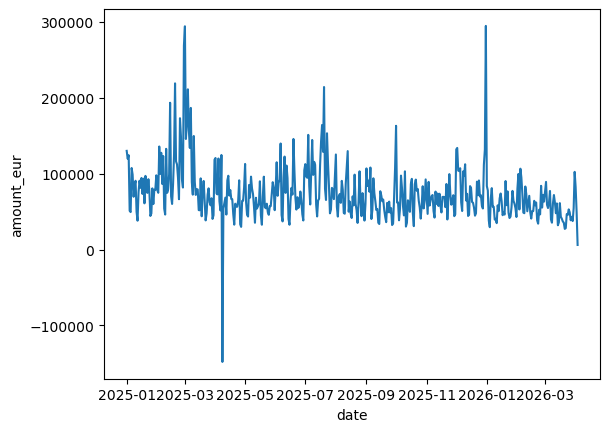

In [9]:
sns.lineplot(dayly, y = 'amount_eur', x = 'date')

Anomaly Detection: Negative Values
A quick look at the plot reveals a sharp drop into negative numbers. This is highly unusual behavior for donations. Let's dig deeper to investigate these negative records.

In [10]:
dayly[dayly.amount_eur < 0]

,date,amount_eur
97,2025-04-08,"-147,998.00"


<Axes: >

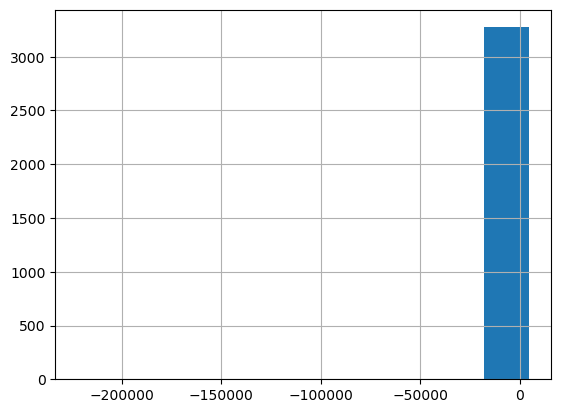

In [11]:
df[df.date == '2025-04-08'].amount_eur.hist()

In [12]:
df[(df['date'] == '2025-04-08') & (df['amount_eur'] < 0)]

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
1524092,"5,346,274.00",2025-04-08,come_back_alive,general,"-221,959.82",45.05,UAH,"Перерахування коштів згідно Додаткової Угоди № 2 від 27.03.2025 р., без ПДВ ...",Повернення коштів
1524866,"5,226,638.00",2025-04-08,come_back_alive,general,-15.54,45.05,UAH,"Віталій Є. -- Благодійна пожертва на Фонд Повернись живим, STN15508792882736375",Monobank


Fortunately, there are only two records with negative donation amounts. This makes it easy to look into the raw data and find out exactly what caused the graph to anomalously drop below zero.

In [13]:
df.loc[1524092, 'comment']

'Перерахування коштів згідно Додаткової Угоди № 2 від 27.03.2025 р., без ПДВ - ПАТ УКРНАФТА'

Translation
"Transfer of funds according to Addendum No. 2 dated March 27, 2025, VAT-exempt - PJSC UKRNAFTA"

Conclusion: This is a corporate accounting correction (likely a refund) from a major oil company. It is a technical transaction, not a regular grassroots donation, and must be removed from our dataset.

In [14]:
df = df[df['amount_eur'] >= 0]

<Axes: xlabel='date', ylabel='amount_eur'>

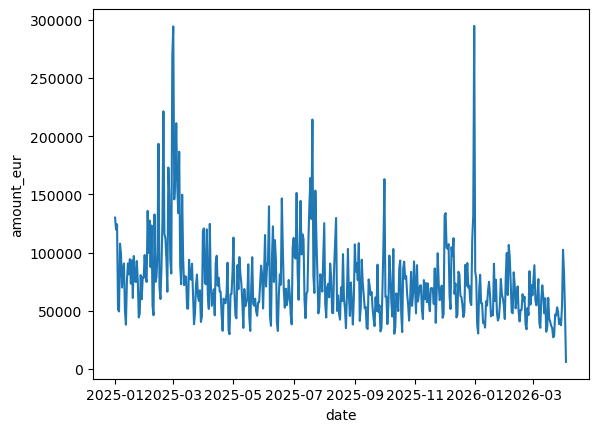

In [15]:
#lets's look at the gpaph now after I fixed it
dayly = df.groupby('date', as_index = False)\
        .agg({'amount_eur':'sum'})

sns.lineplot(dayly, y = 'amount_eur', x = 'date')

Okay, now everything is fine, we can start exploring public donations.

<Axes: xlabel='date', ylabel='amount_eur'>

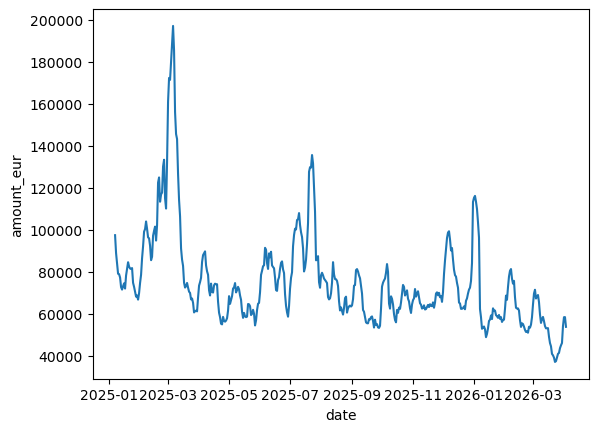

In [18]:
sns.lineplot(y = dayly.amount_eur.rolling(7).mean(), x = dayly.date)

Made the line smoother using rolling window 7 days. From the graph, it is clear that the trend is decreasing; let's verify this using linear regression.

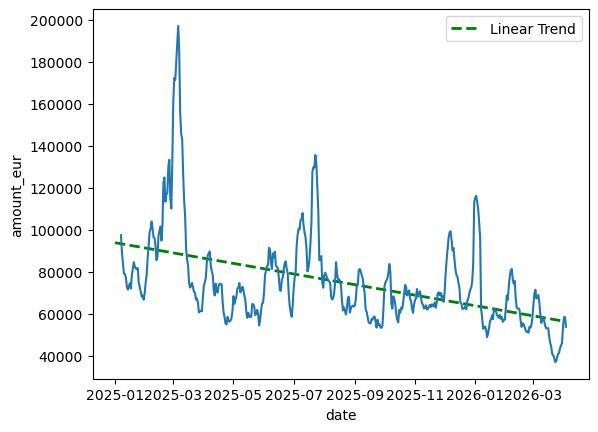

In [22]:
# 1. Convert datetime to numeric values for regression math
x_numeric = mdates.date2num(dayly['date'])
y_values = dayly['amount_eur']

# 2. Calculate linear regression 
coefficients = np.polyfit(x_numeric, y_values, 1)
trend_function = np.poly1d(coefficients)

plt.plot(dayly['date'], trend_function(x_numeric), color='green', linestyle='--', linewidth=2, label='Linear Trend')
sns.lineplot(y = dayly.amount_eur.rolling(7).mean(), x = dayly.date)
plt.legend()

In [33]:
dayly['weekday'] = dayly.date.dt.day_name()

In [34]:
dayly.head()

,date,amount_eur,weekday
0,2025-01-01,"130,061.34",Wednesday
1,2025-01-02,"119,683.82",Thursday
2,2025-01-03,"124,264.38",Friday
3,2025-01-04,"51,121.91",Saturday
4,2025-01-05,"49,418.91",Sunday


Let's see which days people donate most

<Axes: xlabel='weekday', ylabel='amount_eur'>

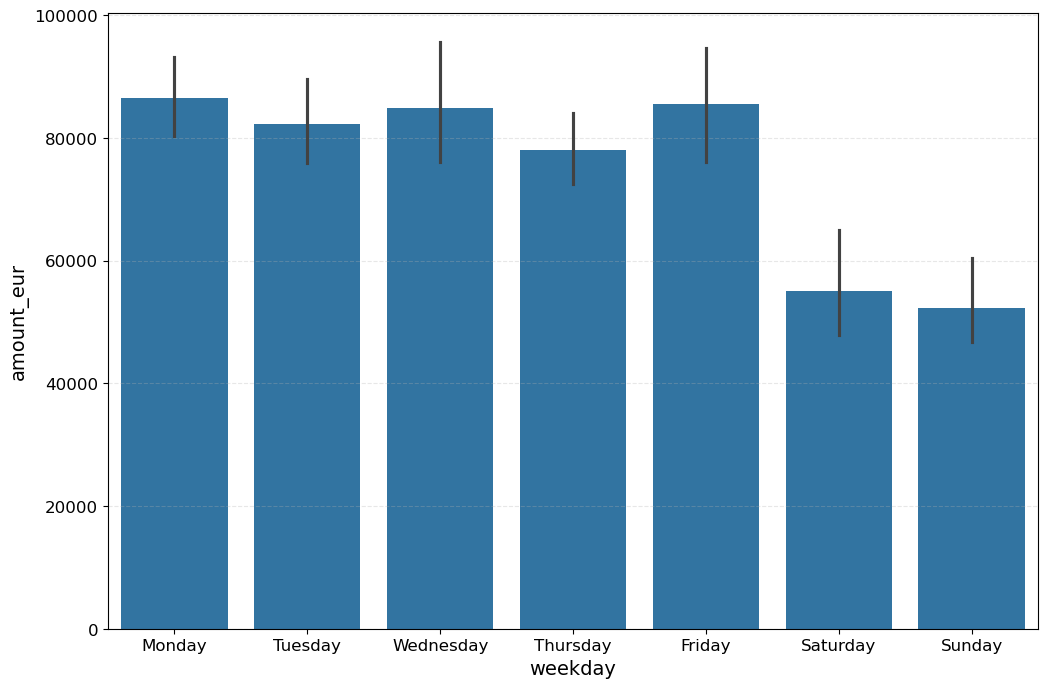

In [41]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x = dayly.weekday, y = dayly.amount_eur, order = order)

<Axes: xlabel='weekday', ylabel='amount_eur'>

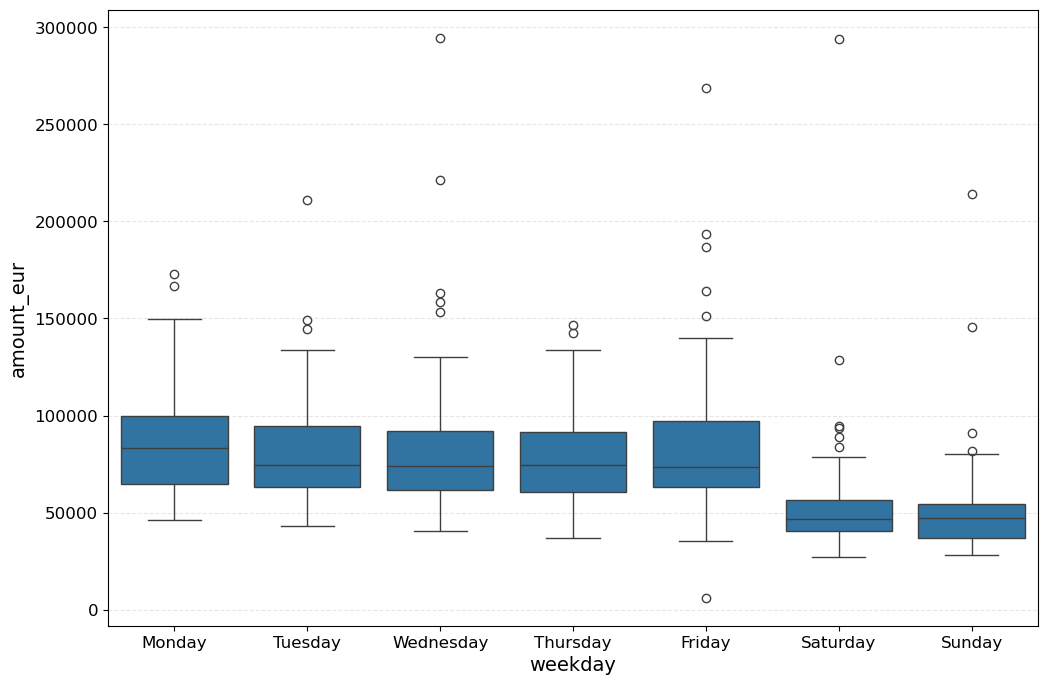

In [42]:
sns.boxplot(x = dayly.weekday, y = dayly.amount_eur, order = order)

We observe a fairly even and logical distribution across the days, with slightly lower values on weekends because many automated services do not operate then. The chart shows that Monday is one of the busiest days (as it includes automated transactions from the weekend). The boxplot also reveals a significant number of outliers, so let’s take a closer look at them.

In [44]:
dayly[dayly.amount_eur > 140000].shape

(21, 3)

In [55]:
dayly[(dayly.weekday.isin(['Saturday', 'Sunday'])) & (dayly.amount_eur > 70000)].shape

(17, 3)

In [57]:
#making two different datasets for working days and weekends for closer look
anomalies_work = dayly[dayly.amount_eur > 140000]
anomalies_week = dayly[(dayly.weekday.isin(['Saturday', 'Sunday'])) & (dayly.amount_eur > 70000)]

Fortunately for us (and unfortunately for the Ukrainian people), we do not have many days with such serious anomalies — only 38 — so we can take a closer look at them.

In [58]:
anomalies_week

,date,amount_eur,weekday
17,2025-01-18,"93,407.18",Saturday
31,2025-02-01,"78,450.19",Saturday
32,2025-02-02,"74,794.37",Sunday
45,2025-02-15,"70,312.26",Saturday
52,2025-02-22,"94,483.60",Saturday
59,2025-03-01,"294,230.65",Saturday
60,2025-03-02,"145,697.32",Sunday
66,2025-03-08,"89,046.91",Saturday
67,2025-03-09,"72,821.83",Sunday
102,2025-04-13,"91,126.42",Sunday
